In [ ]:
# ============================================================
# CLEAN SKY130 GDS → RASTER → FFT (FINAL STABLE VERSION)
# ============================================================

!pip install gdstk

import numpy as np
import torch
import matplotlib.pyplot as plt
import gdstk
from google.colab import files
from matplotlib.path import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ===============================
# 1️⃣ Upload GDS
# ===============================

print("Upload GDS:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

lib = gdstk.read_gds(filename)
cell = lib.top_level()[0]



Upload GDS:


Saving sky130_fd_sc_hd__buf_1.gds to sky130_fd_sc_hd__buf_1 (8).gds


In [ ]:
layers = sorted(set([p.layer for p in cell.polygons]))
print("Available layers:", layers)

layer_id = int(input("Enter layer number: "))

Available layers: [64, 65, 66, 67, 68, 78, 81, 93, 94, 95, 122, 236]
Enter layer number: 66


Target shape: torch.Size([512, 512])


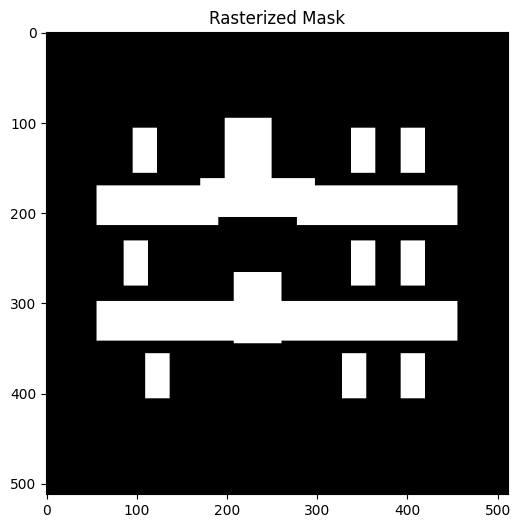

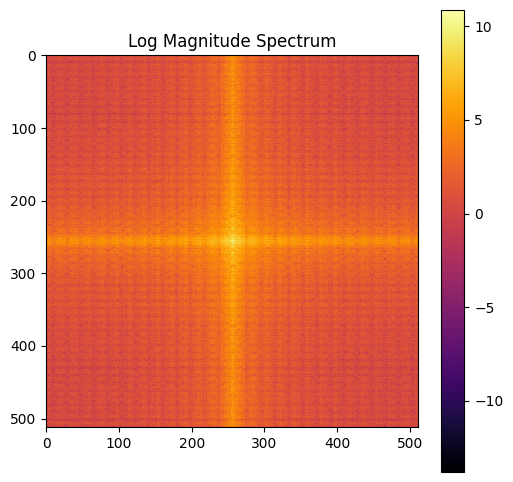

In [ ]:




# ===============================
# 2️⃣ Rasterize
# ===============================

def rasterize(cell, layer, resolution=512):
    polys = [p for p in cell.polygons if p.layer == layer]
    if len(polys) == 0:
        raise ValueError("No polygons found in that layer.")

    (xmin, ymin), (xmax, ymax) = cell.bounding_box()

    img = np.zeros((resolution, resolution))

    xs = np.linspace(xmin, xmax, resolution)
    ys = np.linspace(ymin, ymax, resolution)

    XX, YY = np.meshgrid(xs, ys, indexing="ij")
    points = np.vstack((XX.flatten(), YY.flatten())).T

    for poly in polys:
        vertices = np.array(poly.points)
        path = Path(vertices)
        mask = path.contains_points(points)
        img += mask.reshape(resolution, resolution)

    img = (img > 0).astype(np.float32)
    return torch.tensor(img).to(device)

target = rasterize(cell, layer_id, resolution=512)

print("Target shape:", target.shape)

plt.figure(figsize=(6,6))
plt.imshow(target.cpu(), cmap="gray")
plt.title("Rasterized Mask")
plt.show()

# ===============================
# 3️⃣ FFT
# ===============================

fft_target = torch.fft.fftshift(torch.fft.fft2(target))
magnitude_spectrum = torch.log(torch.abs(fft_target) + 1e-6)

plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum.cpu(), cmap="inferno")
plt.title("Log Magnitude Spectrum")
plt.colorbar()
plt.show()

Top spectral peaks: [(np.int64(264), np.int64(256)), (np.int64(248), np.int64(256)), (np.int64(263), np.int64(256)), (np.int64(249), np.int64(256)), (np.int64(261), np.int64(256)), (np.int64(240), np.int64(256))]


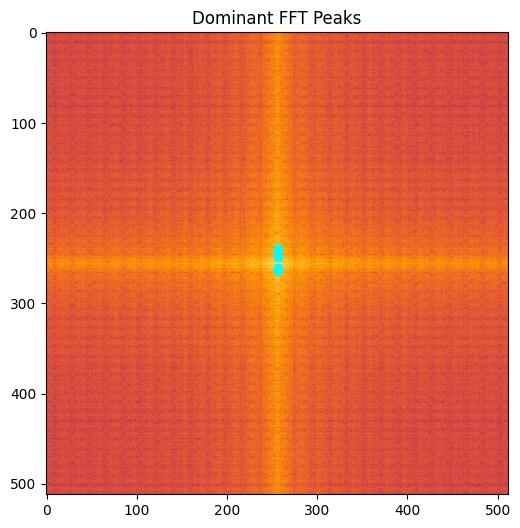

In [ ]:
# ============================================================
# 4️⃣ EXTRACT DOMINANT SPECTRAL PEAKS
# ============================================================

def extract_fft_peaks(fft_tensor, num_peaks=6, exclude_dc_radius=5):
    magnitude = torch.abs(fft_tensor)
    mag_np = magnitude.cpu().numpy()

    center = mag_np.shape[0] // 2

    # Suppress DC region
    mag_np[center-exclude_dc_radius:center+exclude_dc_radius,
           center-exclude_dc_radius:center+exclude_dc_radius] = 0

    flat_indices = np.argsort(mag_np.flatten())[::-1]
    peak_coords = []

    for idx in flat_indices:
        x = idx // mag_np.shape[1]
        y = idx % mag_np.shape[1]

        if len(peak_coords) >= num_peaks:
            break

        peak_coords.append((x, y))

    return peak_coords

peaks = extract_fft_peaks(fft_target, num_peaks=6)
print("Top spectral peaks:", peaks)

# Visualize peaks
plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum.cpu(), cmap='inferno')
for (px, py) in peaks:
    plt.scatter(py, px, color='cyan')
plt.title("Dominant FFT Peaks")
plt.show()

In [ ]:
# ============================================================
# 5️⃣ CONVERT FFT PEAKS TO K-VECTORS
# ============================================================

def fft_index_to_k(idx, resolution, domain_length=2.0):
    center = resolution // 2
    freq = (idx - center) / domain_length
    return 2 * np.pi * freq

resolution = target.shape[0]

k_vectors = []
for (px, py) in peaks:
    kx = fft_index_to_k(px, resolution)
    ky = fft_index_to_k(py, resolution)
    k_vectors.append((kx, ky))

print("Initialized k-vectors:")
for kv in k_vectors:
    print(kv)

Initialized k-vectors:
(np.float64(25.132741228718345), np.float64(0.0))
(np.float64(-25.132741228718345), np.float64(0.0))
(np.float64(21.991148575128552), np.float64(0.0))
(np.float64(-21.991148575128552), np.float64(0.0))
(np.float64(15.707963267948966), np.float64(0.0))
(np.float64(-50.26548245743669), np.float64(0.0))


In [ ]:
# ============================================================
# 6️⃣ PHYSICS-INFORMED BEAM MODEL
# ============================================================

import torch.nn as nn

class SpectralBeamModel(nn.Module):
    def __init__(self, resolution, k_vectors):
        super().__init__()
        self.k_vectors = k_vectors
        self.num_waves = len(k_vectors)

        x = torch.linspace(-1,1,resolution)
        y = torch.linspace(-1,1,resolution)
        self.X, self.Y = torch.meshgrid(x,y,indexing='ij')
        self.X = self.X.to(device)
        self.Y = self.Y.to(device)

        # Only optimize amplitudes first
        self.real = nn.Parameter(torch.randn(self.num_waves)*0.1)
        self.imag = nn.Parameter(torch.randn(self.num_waves)*0.1)

    def forward(self):
        E = 0
        for i,(kx,ky) in enumerate(self.k_vectors):
            phase = kx*self.X + ky*self.Y
            coeff = torch.complex(self.real[i], self.imag[i])
            E += coeff * torch.exp(1j*phase)

        return torch.abs(E)**2

Epoch 0, Loss 0.187386
Epoch 50, Loss 0.121016
Epoch 100, Loss 0.120829
Epoch 150, Loss 0.120828
Epoch 200, Loss 0.120828
Epoch 250, Loss 0.120828


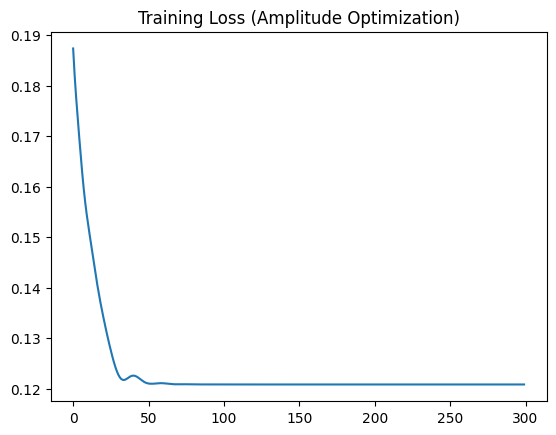

In [ ]:
# ============================================================
# 7️⃣ OPTIMIZE AMPLITUDES (STABLE PHASE)
# ============================================================

model = SpectralBeamModel(resolution, k_vectors).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(300):
    optimizer.zero_grad()
    pred = model()
    loss = loss_fn(pred, target)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.6f}")

plt.plot(loss_history)
plt.title("Training Loss (Amplitude Optimization)")
plt.show()

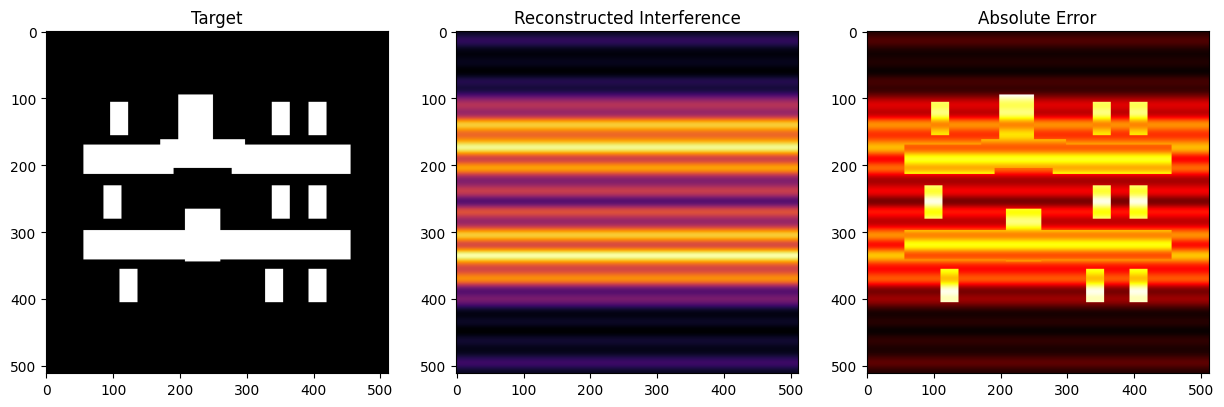

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(target.cpu(), cmap='gray')
plt.title("Target")

plt.subplot(1,3,2)
plt.imshow(pred.detach().cpu(), cmap='inferno')
plt.title("Reconstructed Interference")

plt.subplot(1,3,3)
plt.imshow(torch.abs(pred-target).detach().cpu(), cmap='hot')
plt.title("Absolute Error")

plt.show()

Training localized beam model...
Epoch 0, Loss 0.172772
Epoch 100, Loss 0.072702
Epoch 200, Loss 0.056987
Epoch 300, Loss 0.052466
Epoch 400, Loss 0.049761
Epoch 500, Loss 0.048208


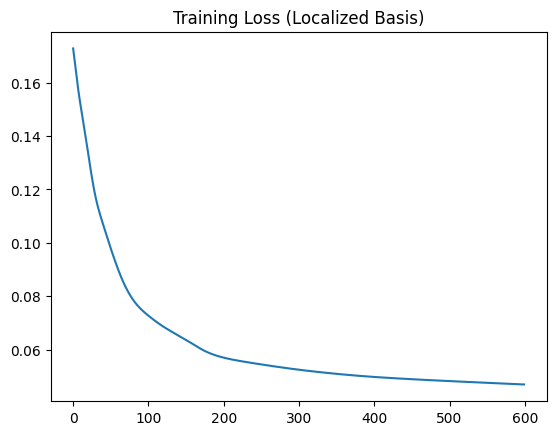

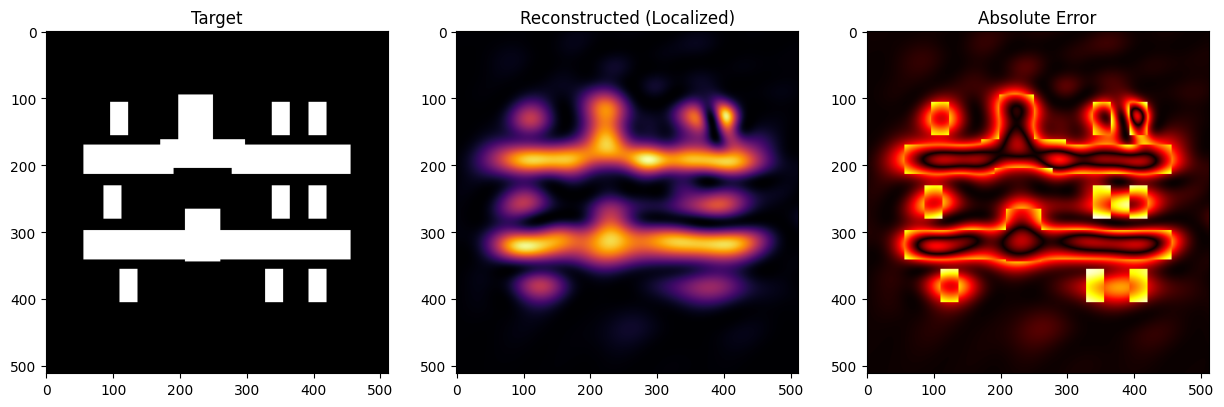

In [ ]:
# ============================================================
# LOCALIZED GAUSSIAN-MODULATED BEAM MODEL
# ============================================================

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resolution = target.shape[0]

# ============================================================
# 1️⃣ Localized Beam Model
# ============================================================

class LocalizedBeamModel(nn.Module):
    def __init__(self, resolution, num_beams=12):
        super().__init__()

        self.num_beams = num_beams

        x = torch.linspace(-1,1,resolution)
        y = torch.linspace(-1,1,resolution)
        self.X, self.Y = torch.meshgrid(x,y,indexing='ij')
        self.X = self.X.to(device)
        self.Y = self.Y.to(device)

        # Wavevector parameters
        self.kx = nn.Parameter(torch.randn(num_beams)*10)
        self.ky = nn.Parameter(torch.randn(num_beams)*10)

        # Amplitudes (complex)
        self.real = nn.Parameter(torch.randn(num_beams)*0.1)
        self.imag = nn.Parameter(torch.randn(num_beams)*0.1)

        # Beam center positions
        self.x0 = nn.Parameter(torch.rand(num_beams)*2 - 1)
        self.y0 = nn.Parameter(torch.rand(num_beams)*2 - 1)

        # Beam widths (positive)
        self.log_sigma = nn.Parameter(torch.zeros(num_beams))

    def forward(self):
        E = 0

        for i in range(self.num_beams):
            phase = self.kx[i]*self.X + self.ky[i]*self.Y
            coeff = torch.complex(self.real[i], self.imag[i])

            sigma = torch.exp(self.log_sigma[i]) + 1e-3
            envelope = torch.exp(
                -((self.X - self.x0[i])**2 +
                  (self.Y - self.y0[i])**2) / (sigma**2)
            )

            E += coeff * torch.exp(1j*phase) * envelope

        return torch.abs(E)**2


# ============================================================
# 2️⃣ Optimization
# ============================================================

model = LocalizedBeamModel(resolution, num_beams=16).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
loss_fn = nn.MSELoss()

loss_history = []

print("Training localized beam model...")

for epoch in range(600):
    optimizer.zero_grad()
    pred = model()
    loss = loss_fn(pred, target)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.6f}")

# ============================================================
# 3️⃣ Visualization
# ============================================================

plt.plot(loss_history)
plt.title("Training Loss (Localized Basis)")
plt.show()

pred = model().detach()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(target.cpu(), cmap='gray')
plt.title("Target")

plt.subplot(1,3,2)
plt.imshow(pred.cpu(), cmap='inferno')
plt.title("Reconstructed (Localized)")

plt.subplot(1,3,3)
plt.imshow(torch.abs(pred-target).cpu(), cmap='hot')
plt.title("Absolute Error")

plt.show()

Training Ewald-constrained localized model...
Epoch 0, Loss 0.180556
Epoch 100, Loss 0.123101
Epoch 200, Loss 0.095832
Epoch 300, Loss 0.085833
Epoch 400, Loss 0.074858
Epoch 500, Loss 0.067257
Epoch 600, Loss 0.065189
Epoch 700, Loss 0.063710


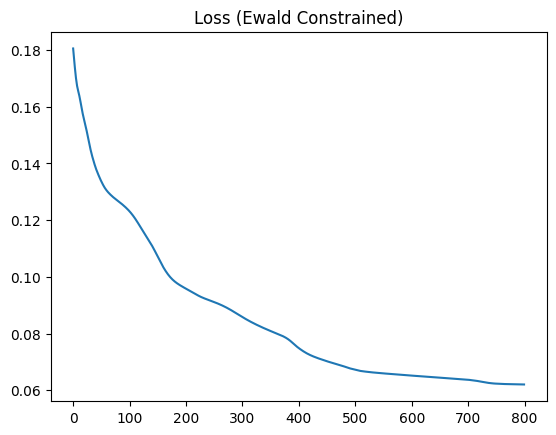

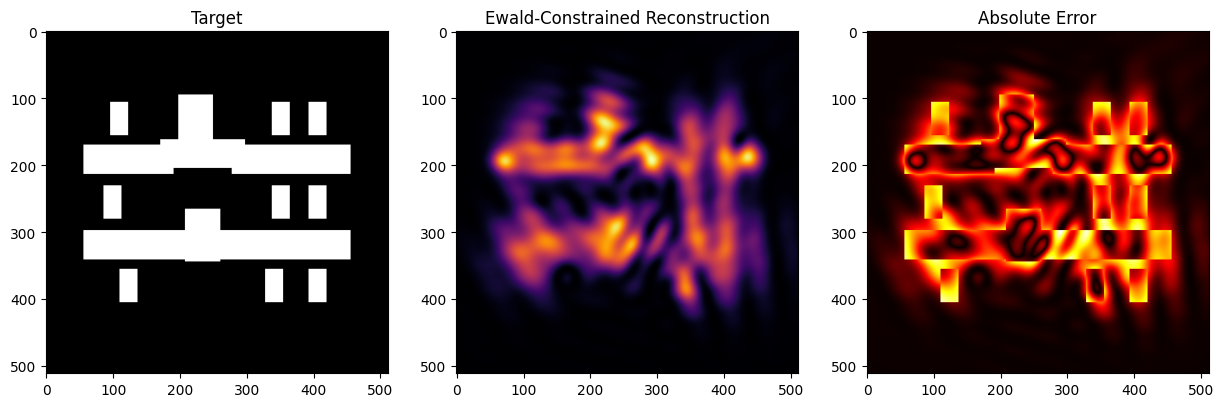

In [ ]:
# ============================================================
# 2D PHYSICALLY CONSTRAINED INTERFERENCE MODEL
# (Ewald circle enforced)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resolution = target.shape[0]

# Define physical wavelength scale
k0 = 25.0   # Controls spatial frequency scale (tune if needed)

class EwaldLocalizedModel(nn.Module):
    def __init__(self, resolution, num_beams=16):
        super().__init__()

        self.num_beams = num_beams

        x = torch.linspace(-1,1,resolution)
        y = torch.linspace(-1,1,resolution)
        self.X, self.Y = torch.meshgrid(x,y,indexing='ij')
        self.X = self.X.to(device)
        self.Y = self.Y.to(device)

        # Angle parameters (only freedom for k direction)
        self.theta = nn.Parameter(torch.rand(num_beams)*2*np.pi)

        # Complex amplitudes
        self.real = nn.Parameter(torch.randn(num_beams)*0.1)
        self.imag = nn.Parameter(torch.randn(num_beams)*0.1)

        # Spatial localization
        self.x0 = nn.Parameter(torch.rand(num_beams)*2 - 1)
        self.y0 = nn.Parameter(torch.rand(num_beams)*2 - 1)

        # Beam width
        self.log_sigma = nn.Parameter(torch.zeros(num_beams))

    def forward(self):
        E = 0

        for i in range(self.num_beams):

            kx = k0 * torch.cos(self.theta[i])
            ky = k0 * torch.sin(self.theta[i])

            phase = kx*self.X + ky*self.Y

            sigma = torch.exp(self.log_sigma[i]) + 1e-3

            envelope = torch.exp(
                -((self.X - self.x0[i])**2 +
                  (self.Y - self.y0[i])**2) / (sigma**2)
            )

            coeff = torch.complex(self.real[i], self.imag[i])

            E += coeff * torch.exp(1j*phase) * envelope

        return torch.abs(E)**2


# ============================================================
# Optimization
# ============================================================

model = EwaldLocalizedModel(resolution, num_beams=16).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
loss_fn = nn.MSELoss()

loss_history = []

print("Training Ewald-constrained localized model...")

for epoch in range(800):
    optimizer.zero_grad()
    pred = model()
    loss = loss_fn(pred, target)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.6f}")

plt.plot(loss_history)
plt.title("Loss (Ewald Constrained)")
plt.show()

pred = model().detach()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(target.cpu(), cmap='gray')
plt.title("Target")

plt.subplot(1,3,2)
plt.imshow(pred.cpu(), cmap='inferno')
plt.title("Ewald-Constrained Reconstruction")

plt.subplot(1,3,3)
plt.imshow(torch.abs(pred-target).cpu(), cmap='hot')
plt.title("Absolute Error")

plt.show()